# Aufbau des Graphen

In [1]:
from pathlib import Path
import sys
import logging

logging.basicConfig(level=logging.INFO)

ROOT = Path.cwd().parent
logging.info(f"Adding {ROOT} to Python path for imports in kernel.")
sys.path.insert(0, str(ROOT))  # ROOT, nicht SRC!

# Load config with changed env path
from mdeagent.config import Config
config = Config.get_instance(env_path=ROOT / ".env")

INFO:root:Adding /Users/lukas/Masterarbeit/agents/bxAgent to Python path for imports in kernel.


In [3]:
from mdeagent.preparation.agent import build_preparation_graph
from mdeagent.evaluation import (
    ToolInstalledEvaluation,
    ToolInstalledEvaluationConfig,
    EvaluationExecutor,
    FileExistenceEvaluation,
    FileExistenceEvaluationConfig,
    JavaCompilationEvaluation,
    JavaCompilationEvaluationConfig,
    WorkspaceStructureEvaluation,
    WorkspaceStructureSchema,
)

executor = EvaluationExecutor(
        evaluations={
            "workspace_structure": {
                "evaluation": WorkspaceStructureEvaluation(),
                "evaluation_schema": WorkspaceStructureSchema,
            },
            "tools_installed": {
                "evaluation": ToolInstalledEvaluation(),
                "evaluation_schema": ToolInstalledEvaluationConfig,
            },
            "file_existence": {
                "evaluation": FileExistenceEvaluation(),
                "evaluation_schema": FileExistenceEvaluationConfig,
            },
            "java_compilation": {
                "evaluation": JavaCompilationEvaluation(),
                "evaluation_schema": JavaCompilationEvaluationConfig,
            },
        }
    )


graph = build_preparation_graph(executor)
compiled_graph = graph.compile()

## Preparation Node

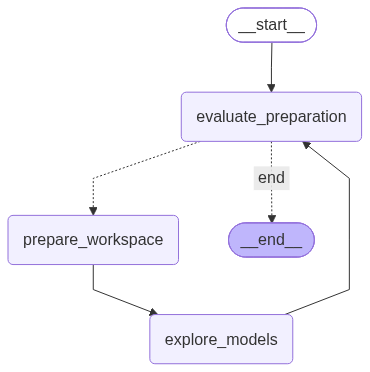

In [4]:
compiled_graph

## Comprehension Node

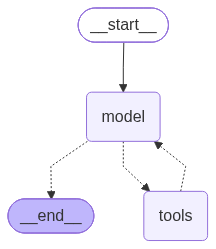

In [ ]:
from mdeagent.agents.comprehension.agent import build_comprehension_agent

comprehension_graph = build_comprehension_agent()
comprehension_graph

## Implementation Node

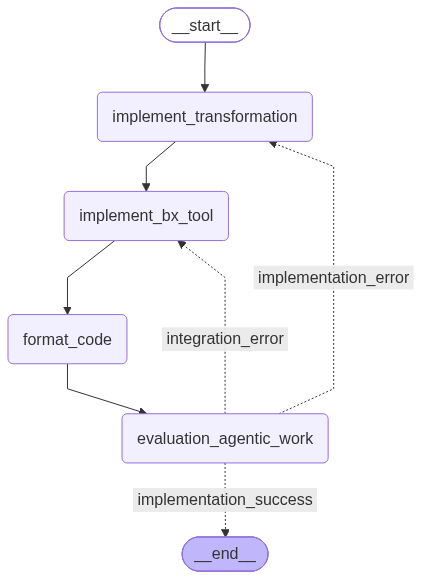

In [ ]:
from mdeagent.implementation.agent import build_implementation_graph
from pathlib import Path

implementation_graph = build_implementation_graph(executor, Path(), Path()).compile()
implementation_graph

## MDEAgent

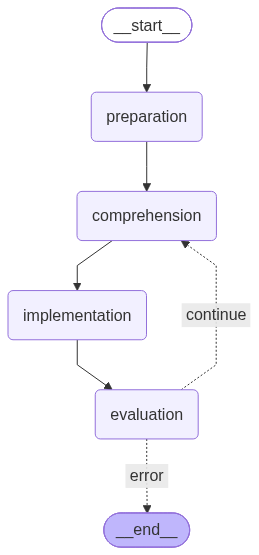

In [5]:
from mdeagent.agent import build_mdeagent

graph = build_mdeagent(executor, Path(), Path()).compile()
graph